In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
customer_df = pd.read_excel('/Users/chrishegangkim/Desktop/2025 Spring/Python/Data Analysis Project/전처리된파일.xlsx')

pd.set_option('display.max_columns', None)
customer_df.head()

,signup_ym,age,annual_income,marital_status,children,recency,amount_alcohol,amount_fruit,amount_meat,amount_fish,amount_snack,amount_general,amount_total,num_purchase_web,num_purchase_store,num_purchase_total,num_purchase_discount,promotion_1,promotion_2,promotion_3,promotion_4,promotion_5,promotion_6
0,2020-12,58,75579400,미혼,0,58,825500,114400,709800,223600,114400,114400,2102100,8,4,15,3,0,0,0,0,0,1
1,2022-06,61,60247200,미혼,2,38,14300,1300,7800,2600,1300,7800,35100,1,2,5,2,0,0,0,0,0,0
2,2021-11,50,93096900,배우자 있음,0,26,553800,63700,165100,144300,27300,54600,1008800,8,10,19,1,0,0,0,0,0,0
3,2022-05,31,34639800,배우자 있음,1,26,14300,5200,26000,13000,3900,6500,68900,2,4,8,2,0,0,0,0,0,0
4,2022-04,34,75780900,배우자 있음,1,94,224900,55900,153400,59800,35100,19500,548600,5,6,16,5,0,0,0,0,0,0


In [7]:
#Recency, Frequency, Monetary 등급 매기기
num_grades = 3

In [8]:
grade_labels = list(range(1, num_grades + 1))
grade_labels

[1, 2, 3]

In [9]:
recency_grade = pd.qcut(x = customer_df['recency'], q = num_grades, labels = grade_labels[::-1])
#1. qcut()으로 x 파라미터에 넣어 준 데이터를 q 파라미터에 넣어 준 값만큼 등분하고 grade_labels을 역순으로 넣기

In [10]:
customer_df['recency_grade'] = recency_grade

In [11]:
customer_df['recency_grade'].value_counts() #1등급부터 3등급까지 비슷한 비율로 나뉘었음을 확인하기

recency_grade
3    757
1    734
2    725
Name: count, dtype: int64

In [22]:
groupby_recency_grade = customer_df.groupby('recency_grade').sum(numeric_only = True).reset_index()
#2. Recency 등급에 따라 매출 기여도가 어떻게 다른지 시각화하기
groupby_recency_grade

/var/folders/kd/8l1qghns69717n72dygjssbh0000gp/T/ipykernel_27098/241863581.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groupby_recency_grade = customer_df.groupby('recency_grade').sum(numeric_only = True).reset_index() #Recency 등급에 따라 매출 기여가 어떻게 다른지 시각화하기


,recency_grade,age,annual_income,children,recency,amount_alcohol,amount_fruit,amount_meat,amount_fish,amount_snack,amount_general,amount_total,num_purchase_web,num_purchase_store,num_purchase_total,num_purchase_discount,promotion_1,promotion_2,promotion_3,promotion_4,promotion_5,promotion_6
0,3,34596,52161527600,682,12099,294151000,26768300,161978700,37629800,25547600,42512600,588588000,3107,4393,9213,1713,54,12,67,55,60,179
1,2,33897,48503598000,725,35913,295105200,23864100,152484800,35184500,25230400,41570100,573439100,2997,4245,9014,1772,47,8,47,52,49,95
2,1,33841,49848756100,692,60600,289651700,25294100,166618400,35612200,27086800,42572400,586835600,2949,4217,8830,1664,41,10,49,57,53,59


<Axes: ylabel='amount_total'>

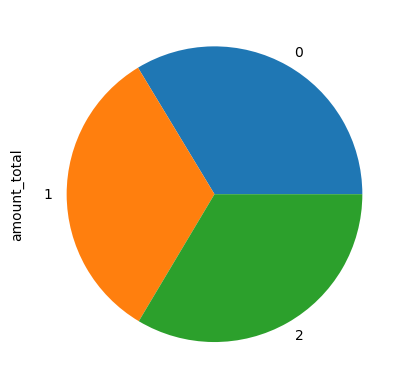

In [30]:
groupby_recency_grade['amount_total'].plot(kind = 'pie') #3. 파이 차트 그리기

<Axes: title={'center': 'Recency 등급별 매출 기여도'}>

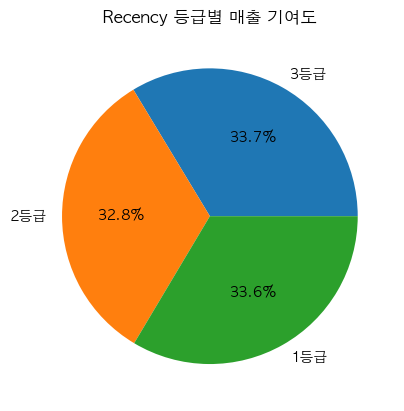

In [34]:
plt.rc('font', family = 'AppleGothic') #한글 지원 폰트를 설정하기
groupby_recency_grade['amount_total'].plot(kind = 'pie', autopct = '%.1f%%', labels = [f'{x}등급' for x in grade_labels[::-1]],
                                          title = 'Recency 등급별 매출 기여도', ylabel = '')
#autopct 파라미터에 '%.1f%%'를 넣어서 파이 차트 내 각 영역의 비중 퍼센트를 소수 첫 번째 자리까지 표시하기

In [38]:
customer_df['frequency_grade'] = pd.qcut(x = customer_df['num_purchase_total'], q = num_grades, labels = grade_labels) #1. Frequency 등급 매기기

In [40]:
customer_df['frequency_grade'].value_counts()

frequency_grade
1    859
2    681
3    676
Name: count, dtype: int64

/var/folders/kd/8l1qghns69717n72dygjssbh0000gp/T/ipykernel_27098/3864880879.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groupby_frequency_grade = customer_df.groupby('frequency_grade').sum(numeric_only = True).reset_index()#2. Frequency 등급별 매출 기여도를 파이 차트로 그리기


<Axes: title={'center': 'Frequency 등급별 매출 기여도'}>

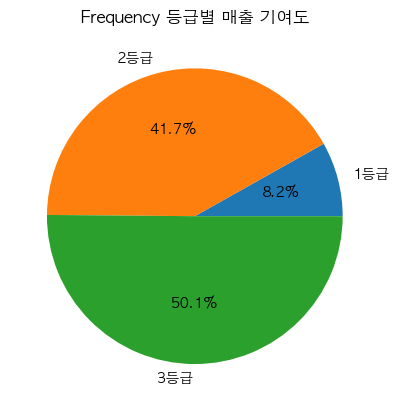

In [60]:
groupby_frequency_grade = customer_df.groupby('frequency_grade').sum(numeric_only = True).reset_index()
#2 & 3. Frequency 등급별 매출 기여도를 파이 차트로 그리기
groupby_frequency_grade['amount_total'].plot(kind = 'pie', autopct = '%.1f%%', labels = [f'{x}등급' for x in grade_labels],
                                             title = 'Frequency 등급별 매출 기여도', ylabel = '')

In [64]:
#1. 등급 나누기 2. 등급별 매출 기여도 시각화하기 3. 파라미터들을 넣어서 파이 차트 그리기
customer_df['monetary_grade'] = pd.qcut(x = customer_df['amount_total'], q = num_grades, labels = grade_labels)
customer_df['monetary_grade'].value_counts()

monetary_grade
1    739
3    739
2    738
Name: count, dtype: int64

In [66]:
groupby_monetary_grade = customer_df.groupby('monetary_grade').sum(numeric_only = True).reset_index()

/var/folders/kd/8l1qghns69717n72dygjssbh0000gp/T/ipykernel_27098/3921467696.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groupby_monetary_grade = customer_df.groupby('monetary_grade').sum(numeric_only = True).reset_index()


<Axes: title={'center': 'Monetary 등급별 매출 기여도'}>

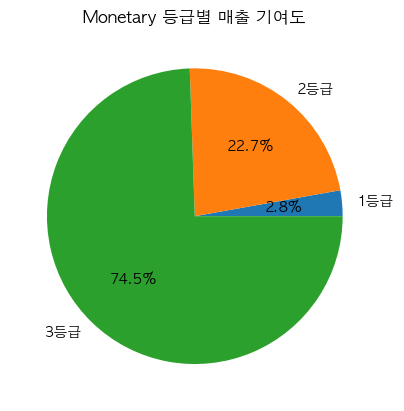

In [76]:
groupby_monetary_grade['amount_total'].plot(kind = 'pie', autopct = '%.1f%%', labels = [f'{x}등급' for x in grade_labels],
                                            title = 'Monetary 등급별 매출 기여도', ylabel = '')

In [78]:
#가중합을 이용해 RFM 고객 세그먼트 분류하기
weight = {}
weight['recency'] = 1 / 3
weight['frequency'] = 1 / 3
weight['monetary'] = 1 / 3

In [80]:
customer_df['rfm_score'] = (weight['recency'] * customer_df['recency_grade'].astype('int') #가중치와 등급을 곱한 뒤 더하기
    + weight['frequency'] * customer_df['frequency_grade'].astype('int')
    + weight['monetary'] * customer_df['monetary_grade'].astype('int'))

In [82]:
def rfm_segment_bins(x): #세 구간의 크기가 모두 2/3이지만 구간 경계의 포함 여부가 일관되지 않은 경우에는 apply() 함수를 이용하기
    if x < 5 / 3:
        return 1
    elif x <= 7 / 3:
        return 2
    else:
        return 3

In [84]:
customer_df['rfm_segment'] = customer_df['rfm_score'].apply(rfm_segment_bins) #rfm_score 컬럼의 값 하나하나가 rfm_segment_bins() 함수를 통과함

In [86]:
customer_df['rfm_segment'].value_counts()

rfm_segment
1    931
2    816
3    469
Name: count, dtype: int64

<Axes: title={'center': 'RFM 고객 세그먼트별 매출 기여도'}>

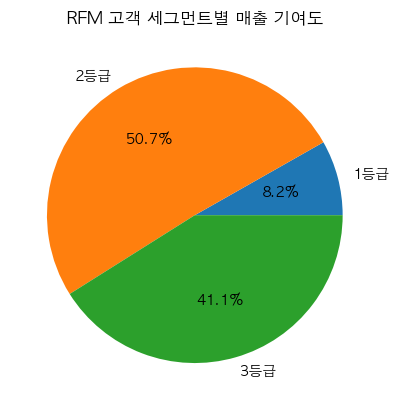

In [90]:
groupby_rfm_segment = customer_df.groupby('rfm_segment').sum(numeric_only = True).reset_index()
groupby_rfm_segment['amount_total'].plot(kind = 'pie', autopct = '%.1f%%', labels = [f'{x}등급' for x in grade_labels],
                                            title = 'RFM 고객 세그먼트별 매출 기여도', ylabel = '')

In [92]:
# 가중치 재설정
weight['recency'] = 0.2
weight['frequency'] = 0.4
weight['monetary'] = 0.4

# 가중합 계산
customer_df['rfm_score'] = (
    weight['recency'] * customer_df['recency_grade'].astype('int')
    + weight['frequency'] * customer_df['frequency_grade'].astype('int')
    + weight['monetary'] * customer_df['monetary_grade'].astype('int')
)

# RFM 고객 지표 구간화
customer_df['rfm_segment'] = customer_df['rfm_score'].apply(rfm_segment_bins)


In [94]:
customer_df['rfm_segment'].value_counts()

rfm_segment
1    807
3    793
2    616
Name: count, dtype: int64

<Axes: title={'center': 'RFM 고객 세그먼트별 매출 기여도'}>

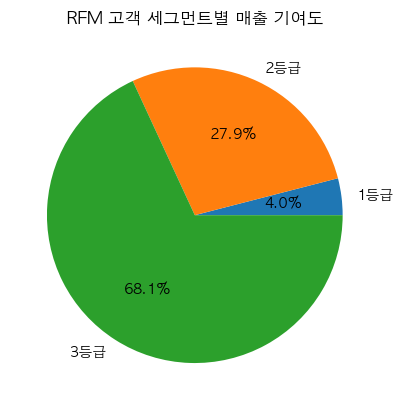

In [96]:
groupby_rfm_segment = customer_df.groupby('rfm_segment').sum(numeric_only = True).reset_index()
groupby_rfm_segment['amount_total'].plot(kind = 'pie', autopct = '%.1f%%', labels = [f'{x}등급' for x in grade_labels],
                                            title = 'RFM 고객 세그먼트별 매출 기여도', ylabel = '')

In [98]:
customer_df.to_excel('RFM세그먼트분류.xlsx', index = False)